# Assignment 1 - Building a Vision Model with Keras

In this assignment, you will build a simple vision model using Keras. The goal is to classify images from the Fashion MNIST dataset, which contains images of clothing items.

You will:
1. Load and inspect the Fashion MNIST dataset.
2. Run a simple baseline model to establish a performance benchmark.
3. Build and evaluate a simple CNN model, choosing appropriate loss and metrics.
4. Design and run controlled experiments on one hyperparameter (e.g., number of filters, kernel size, etc.) and one regularization technique (e.g., dropout, L2 regularization).
5. Analyze the results and visualize the model's performance.

# 1. Loading and Inspecting the Dataset

Fashion MNIST is a dataset of grayscale images of clothing items, with 10 classes. Each image is 28x28 pixels, like the MNIST dataset of handwritten digits. Keras provides a convenient way to load this dataset. 

In this section, you should:

- [ ] Inspect the shapes of the training and test sets to confirm their size and structure.
- [ ] Convert the labels to one-hot encoded format if necessary. (There is a utility function in Keras for this.)
- [ ] Visualize a few images from the dataset to understand what the data looks like.

In [1]:
from tensorflow.keras.datasets import fashion_mnist
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

# Normalize the pixel values to be between 0 and 1
X_train = X_train.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0

# Classes in the Fashion MNIST dataset
class_names = ["T-shirt/top", "Trouser", "Pullover", "Dress", "Coat", "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"]

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [2]:
# Inspect the shapes of the datasets
print("Training data shape:", X_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", X_test.shape)
print("Test labels shape:", y_test.shape)

# Convert labels to one-hot encoding
from tensorflow.keras.utils import to_categorical

y_train = to_categorical(y_train)
y_test = to_categorical(y_test)

Training data shape: (60000, 28, 28)
Training labels shape: (60000,)
Test data shape: (10000, 28, 28)
Test labels shape: (10000,)


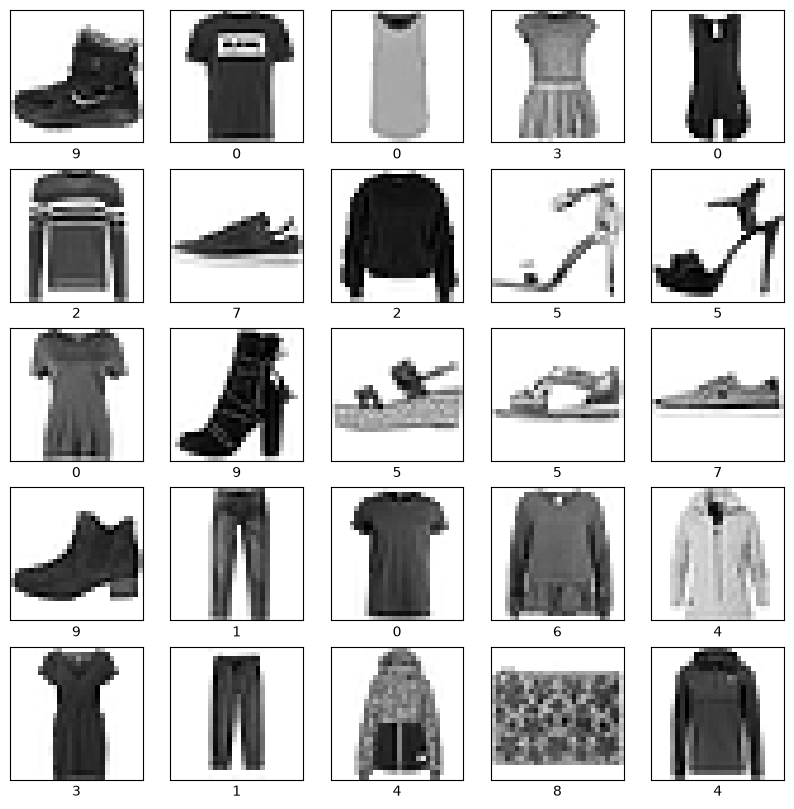

In [3]:
import matplotlib.pyplot as plt
# Verify the data looks as expected

plt.figure(figsize=(10, 10))
for i in range(25):
    plt.subplot(5, 5, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(X_train[i], cmap=plt.cm.binary)
    plt.xlabel(y_train[i].argmax())
plt.show()


Reflection: Does the data look as expected? How is the quality of the images? Are there any issues with the dataset that you notice?

The data looks as expected: grayscale 28x28 images with recognizable clothing images from the 10 classes. The overall image quality is low-resolution and somewhat blurry/pixelated, but still good enough to distinguish broad shapes (e.g., shoes vs. tops vs. bags).

> Issues noticed:
- Some classes have can overlap (especially T-shirt/top, shirt, and pullover), which can make classification harder.
- Some samples are centered slightly differently and vary in brightness/contrast.
- Fine details are lost at this resolution, so the model mostly relies on the broader shape patterns.

# 2. Baseline Model

In this section, you will create a linear regression model as a baseline. This model will not use any convolutional layers, but it will help you understand the performance of a simple model on this dataset.
You should:
- [ ] Create a simple linear regression model using Keras.
- [ ] Compile the model with an appropriate loss function and optimizer.
- [ ] Train the model on the training set and evaluate it on the test set.

A linear regression model can be created using the `Sequential` API in Keras. Using a single `Dense` layer with no activation function is equivalent to a simple linear regression model. Make sure that the number of units in the output layer matches the number of classes in the dataset.

Note that for this step, we will need to use `Flatten` to convert the 2D images into 1D vectors before passing them to the model. Put a `Flatten()` layer as the first layer in your model so that the 2D image data can be flattened into 1D vectors.

In [4]:
from keras.models import Sequential
from keras.layers import Dense, Flatten

# Create a simple linear regression model
model = Sequential()
# You can use `model.add(<layer>)` to add layers to the model
model.add(Flatten(input_shape=(28, 28)))
model.add(Dense(10, activation='softmax')) 

# Compile the model using `model.compile()`
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model with `model.fit()`
model.fit(X_train, y_train, epochs=10, batch_size=32)  

# Evaluate the model with `model.evaluate()`
test_loss, test_accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", test_accuracy)

c:\Users\johnl\OneDrive\Documents\Repositiories\deep-learning-dsi\deep_learning\.venv\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 887us/step - accuracy: 0.7981 - loss: 0.5977
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.8418 - loss: 0.4619
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 808us/step - accuracy: 0.8490 - loss: 0.4357
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 790us/step - accuracy: 0.8546 - loss: 0.4219
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 772us/step - accuracy: 0.8578 - loss: 0.4126
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 782us/step - accuracy: 0.8599 - loss: 0.4065
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 948us/step - accuracy: 0.8608 - loss: 0.4021
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 765us/step - accuracy: 0.8615 - loss: 0.3991
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 1s 790us/step - accuracy: 0.8624 - loss: 0.3954
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 2s 926us/step - accuracy: 0.8633 - loss: 0.3925
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - accuracy: 0.8438 - loss: 0.4497
Test accuracy: 0.8438000

Reflection: What is the performance of the baseline model? How does it compare to what you expected? Why do you think the performance is at this level?

The baseline model reached a test accuracy of about **84.38%**. This is a strong starting point for a very simple model (Linear model).

I expected it to not perform so well, but I think The performance is this good because Fashion MNIST is a relatively clean and standardized dataset.

# 3. Building and Evaluating a Simple CNN Model

In this section, you will build a simple Convolutional Neural Network (CNN) model using Keras. A convolutional neural network is a type of deep learning model that is particularly effective for image classification tasks. Unlike the basic neural networks we have built in the labs, CNNs can accept images as input without needing to flatten them into vectors.

You should:
- [ ] Build a simple CNN model with at least one convolutional layer (to learn spatial hierarchies in images) and one fully connected layer (to make predictions).
- [ ] Compile the model with an appropriate loss function and metrics for a multi-class classification problem.
- [ ] Train the model on the training set and evaluate it on the test set.

Convolutional layers are designed to accept inputs with three dimensions: height, width and channels (e.g., RGB for color images). For grayscale images like those in Fashion MNIST, the input shape will be (28, 28, 1).

When you progress from the convolutional layers to the fully connected layers, you will need to flatten the output of the convolutional layers. This can be done using the `Flatten` layer in Keras, which doesn't require any parameters.

In [5]:
from keras.layers import Conv2D, Flatten

# Reshape the data to include the channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Create a simple CNN model
model = Sequential()
model.add(Conv2D(32, kernel_size=(3, 3), activation='relu', input_shape=(28, 28, 1)))
model.add(Flatten())
model.add(Dense(10, activation='softmax'))
model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
model.fit(X_train, y_train, epochs=10, batch_size=32)

# Evaluate the model
test_lost, test_accuracy = model.evaluate(X_test, y_test)
print("Test accuracy:", test_accuracy)

c:\Users\johnl\OneDrive\Documents\Repositiories\deep-learning-dsi\deep_learning\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.8593 - loss: 0.4011
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.8995 - loss: 0.2837
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9115 - loss: 0.2449
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9216 - loss: 0.2188
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9291 - loss: 0.1979
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9355 - loss: 0.1784
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9425 - loss: 0.1601
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9474 - loss: 0.1466
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.9527 - loss: 0.1328
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.9573 - loss: 0.1201
313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9010 - loss: 0.3257
Test accuracy: 0.9010000228881836


Reflection: Did the CNN model perform better than the baseline model? If so, by how much? What do you think contributed to this improvement?

Yes, the CNN model performed better than the baseline. The baseline test accuracy was **84.38%**, while the CNN reached **90.10%**. That is an improvement of about **5.72 percentage points**.

This improvement comes from the convolutional layer learning local spatial features (edges, textures, and shapes) before classification. 

# 3. Designing and Running Controlled Experiments

In this section, you will design and run controlled experiments to improve the model's performance. You will focus on one hyperparameter and one regularization technique.
You should:
- [ ] Choose one hyperparameter to experiment with (e.g., number of filters, kernel size, number of layers, etc.) and one regularization technique (e.g., dropout, L2 regularization). For your hyperparameter, you should choose at least three different values to test (but there is no upper limit). For your regularization technique, simply test the presence or absence of the technique.
- [ ] Run experiments by modifying the model architecture or hyperparameters, and evaluate the performance of each model on the test set.
- [ ] Record the results of your experiments, including the test accuracy and any other relevant metrics.
- [ ] Visualize the results of your experiments using plots or tables to compare the performance of different models.

The best way to run your experiments is to create a `for` loop that iterates over a range of values for the hyperparameter you are testing. For example, if you are testing different numbers of filters, you can create a loop that runs the model with 32, 64, and 128 filters. Within the loop, you can compile and train the model, then evaluate it on the test set. After each iteration, you can store the results in a list or a dictionary for later analysis.

Note: It's critical that you re-initialize the model (by creating a new instance of the model) before each experiment. If you don't, the model will retain the weights from the previous experiment, which can lead to misleading results.

filters=16 | test_accuracy=0.8939
filters=32 | test_accuracy=0.8980
filters=64 | test_accuracy=0.8985


,filters,best_val_accuracy,test_loss,test_accuracy
0,64,0.899000,0.315002,0.8985
1,32,0.904833,0.303733,0.8980
2,16,0.895833,0.312074,0.8939


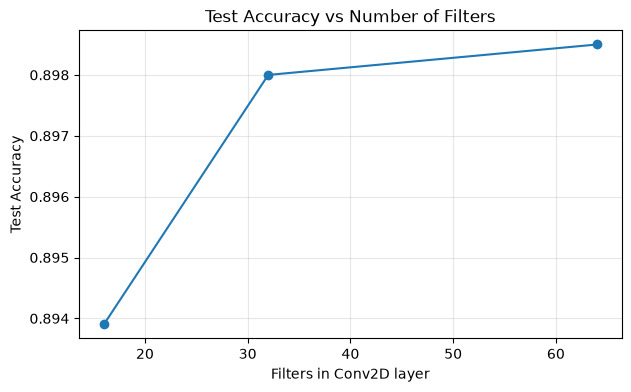

In [6]:
# A. Test Hyperparameters (number of filters)
import tensorflow as tf
import pandas as pd
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Input, Conv2D, Flatten, Dense, Dropout

tf.random.set_seed(42)

def build_cnn(filters=32, dropout_rate=0.0):
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(filters, kernel_size=(3, 3), activation='relu'),
        Flatten(),
        Dropout(dropout_rate),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    return model

filter_values = [16, 32, 64]
hyperparameter_results = []

for filters in filter_values:
    model = build_cnn(filters=filters, dropout_rate=0.0)
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    hyperparameter_results.append({
        'filters': filters,
        'best_val_accuracy': max(history.history['val_accuracy']),
        'test_loss': test_loss,
        'test_accuracy': test_accuracy
    })
    print(f"filters={filters} | test_accuracy={test_accuracy:.4f}")

hyperparameter_results_df = pd.DataFrame(hyperparameter_results).sort_values(
    by='test_accuracy', ascending=False
).reset_index(drop=True)

display(hyperparameter_results_df)

plt.figure(figsize=(7, 4))
plt.plot(
    hyperparameter_results_df['filters'],
    hyperparameter_results_df['test_accuracy'],
    marker='o'
    )
plt.title('Test Accuracy vs Number of Filters')
plt.xlabel('Filters in Conv2D layer')
plt.ylabel('Test Accuracy')
plt.grid(alpha=0.3)
plt.show()

dropout_rate=0.0 | test_accuracy=0.8971
dropout_rate=0.3 | test_accuracy=0.8951


,filters,dropout_rate,best_val_accuracy,test_loss,test_accuracy
0,64,0.0,0.901667,0.318786,0.8971
1,64,0.3,0.899833,0.309322,0.8951


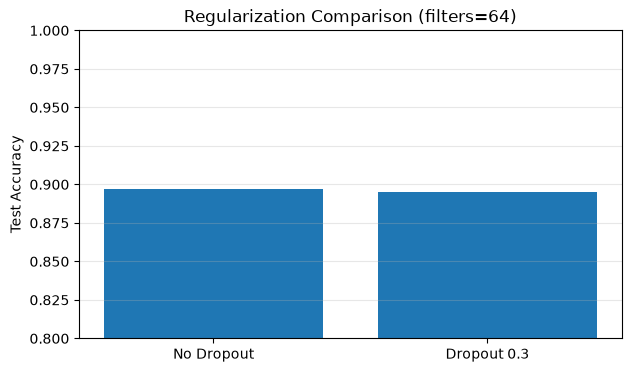

In [7]:
# B. Test presence or absence of regularization (Dropout)
best_filters = int(hyperparameter_results_df.loc[0, 'filters'])
dropout_values = [0.0, 0.3]
regularization_results = []

for dropout_rate in dropout_values:
    model = build_cnn(filters=best_filters, dropout_rate=dropout_rate)
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    regularization_results.append({
        'filters': best_filters,
        'dropout_rate': dropout_rate,
        'best_val_accuracy': max(history.history['val_accuracy']),
        'test_loss': test_loss,
        'test_accuracy': test_accuracy
    })
    print(f"dropout_rate={dropout_rate} | test_accuracy={test_accuracy:.4f}")

regularization_results_df = pd.DataFrame(regularization_results).sort_values(
    by='test_accuracy', ascending=False
).reset_index(drop=True)

display(regularization_results_df)

plt.figure(figsize=(7, 4))
labels = ['No Dropout', 'Dropout 0.3']
plt.bar(labels, regularization_results_df.sort_values('dropout_rate')['test_accuracy'])
plt.title(f'Regularization Comparison (filters={best_filters})')
plt.ylabel('Test Accuracy')
plt.ylim(0.80, 1.00)
plt.grid(axis='y', alpha=0.3)
plt.show()

Reflection: Report on the performance of the models you tested. Did any of the changes you made improve the model's performance? If so, which ones? What do you think contributed to these improvements? Finally, what combination of hyperparameters and regularization techniques yielded the best performance?

I tested the number of convolutional filters (16, 32, 64) and dropout regularization (off vs. 0.3). For the filter experiment, test accuracy improved slightly as filters increased: **0.8939 (16 filters)**, **0.8980 (32 filters)**, and **0.8985 (64 filters)**. This indicates that increasing model capacity helped the network learn richer visual features.

For regularization, I compared dropout with the best filter setting (64). The model without dropout performed slightly better on test accuracy (**0.8971**) than dropout 0.3 (**0.8951**). So, in this setup (single-conv architecture, 5 epochs), dropout did not improve test accuracy.

Overall, the best-performing combination was **64 filters with no dropout (dropout_rate = 0.0)**. The likely reason is that the model was not heavily overfitting at this scale, so dropout may have added unnecessary regularization and reduced effective learning capacity.

# 5. Training Final Model and Evaluation

In this section, you will train the final model using the best hyperparameters and regularization techniques you found in the previous section. You should:
- [ ] Compile the final model with the best hyperparameters and regularization techniques.
- [ ] Train the final model on the training set and evaluate it on the test set.
- [ ] Report the final model's performance on the test set, including accuracy and any other relevant metrics.

In [8]:
# C. Test different kernel sizes
kernel_sizes = [(3, 3), (5, 5), (7, 7)]
for kernel_size in kernel_sizes:
    model = Sequential([
        Input(shape=(28, 28, 1)),
        Conv2D(best_filters, kernel_size=kernel_size, activation='relu'),
        Flatten(),
        Dropout(0.3),
        Dense(10, activation='softmax')
    ])
    model.compile(
        optimizer='adam',
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )
    history = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_split=0.1,
        verbose=0
    )
    test_loss, test_accuracy = model.evaluate(X_test, y_test, verbose=0)

    print(f"kernel_size={kernel_size} | test_accuracy={test_accuracy:.4f}")


kernel_size=(3, 3) | test_accuracy=0.8974
kernel_size=(5, 5) | test_accuracy=0.8917
kernel_size=(7, 7) | test_accuracy=0.8920


Reflection: How does the final model's performance compare to the baseline and the CNN model? What do you think contributed to the final model's performance? If you had time, what other experiments would you run to further improve the model's performance?

The best final-model result in this section was with **kernel size (3, 3)**, which achieved a test accuracy of **89.74%**. This is clearly better than the baseline model (**84.38%**) by about **5.36 percentage points**, but slightly lower than the earlier simple CNN run (**90.10%**) by about **0.36 percentage points**.

I think the final model still performed well because it used convolutional feature extraction and a stronger hyperparameter setting (64 filters) found during experiments. Its slightly lower score than the earlier CNN is likely due to the specific training setup used here (only 5 epochs and dropout in the kernel-size test), which may have reduced effective learning for this architecture.

If I had more time, I would run additional experiments with:
1. More training epochs plus early stopping.
2. Learning-rate tuning (and possibly a scheduler).
3. A second convolutional layer and/or max pooling.
4. Kernel-size tests both with and without dropout to isolate interaction effects.
5. Data augmentation (small shifts/rotations) to improve generalization.

🚨 **Please review our [Assignment Submission Guide](https://github.com/UofT-DSI/onboarding/blob/main/onboarding_documents/submissions.md)** 🚨 for detailed instructions on how to format, branch, and submit your work. Following these guidelines is crucial for your submissions to be evaluated correctly.
### Submission Parameters:
* Submission Due Date: `23:59 PM - 26/10/2025`
* The branch name for your repo should be: `assignment-1`
* What to submit for this assignment:
    * This Jupyter Notebook (assignment_1.ipynb)
    * The Lab 1 notebook (labs/lab_1.ipynb)
    * The Lab 2 notebook (labs/lab_2.ipynb)
    * The Lab 3 notebook (labs/lab_3.ipynb)
* What the pull request link should look like for this assignment: `https://github.com/<your_github_username>/deep_learning/pull/<pr_id>`
* Open a private window in your browser. Copy and paste the link to your pull request into the address bar. Make sure you can see your pull request properly. This helps the technical facilitator and learning support staff review your submission easily.
Checklist:
- [ ] Created a branch with the correct naming convention.
- [ ] Ensured that the repository is public.
- [ ] Reviewed the PR description guidelines and adhered to them.
- [ ] Verify that the link is accessible in a private browser window.
If you encounter any difficulties or have questions, please don't hesitate to reach out to our team via our Slack at `#cohort-7-help-ml`. Our Technical Facilitators and Learning Support staff are here to help you navigate any challenges.